## FIRST Logistic Regression

### 1. Подключаем необходимые библиотеки и генерируем датасет

In [1]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.datasets import make_blobs
import matplotlib.pyplot as plt
np.random.seed(123)

In [2]:
X, y = make_blobs(n_samples = 1000, centers = 2)

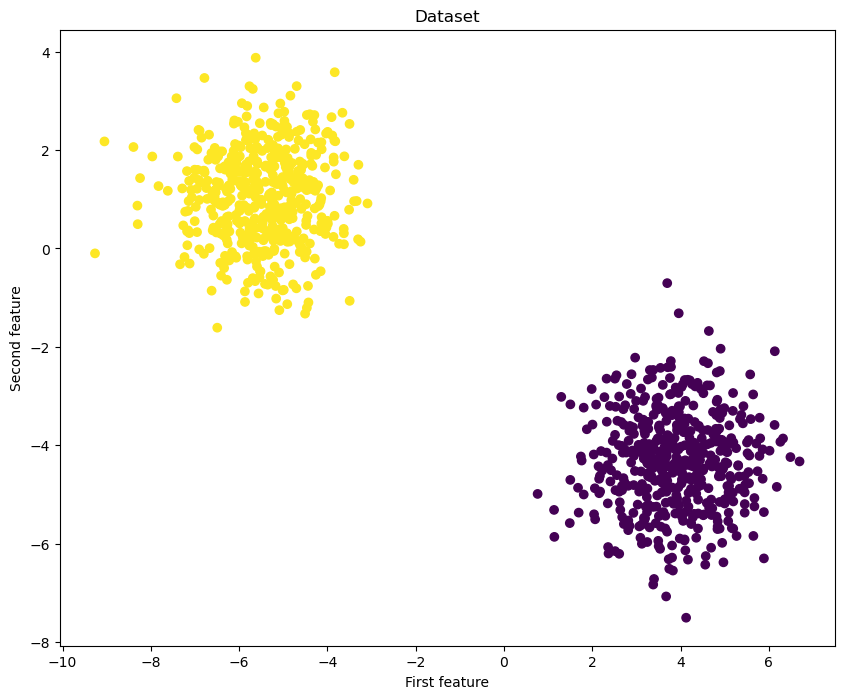

In [3]:
fig = plt.figure(figsize=(10,8))
plt.scatter(X[:,0], X[:,1], c=y)
plt.title("Dataset")
plt.xlabel("First feature")
plt.ylabel("Second feature")
plt.show()

### 1.1 Делим созданный датасет на тренировочную и тестовую выборки

In [4]:
y = np.vstack(y)
X_train, X_test, y_train, y_test = train_test_split(X, y)
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((750, 2), (250, 2), (750, 1), (250, 1))

### 2. Создаем класс LogisticRegres и обучаем модель

In [5]:
class LogisticRegres:
    def init(model):
        pass

    def sigmoid(model, X):
        return np.vstack(1 / (1 + np.exp(-(np.dot(X, model.weights) + model.bias))))
        
    def gradientdescent(model, X, y, cost_iter = 0.04, count_iter = 700):
        model.weights = np.vstack(np.zeros(X.shape[1]))
        model.bias = 0
        costs = []
        
        for i in range(count_iter):
            costs.append((-1 / X.shape[0]) * np.sum(y * np.log(model.sigmoid(X)) + (1 - y) * np.log(1 - model.sigmoid(X))))
            if i % 100 == 0:
                print(f"Cost on {i} iterations = {costs[i]}")
        
            dJ_dw = (1/X.shape[0]) * (np.dot(X.T, (model.sigmoid(X) - y)))
            dJ_db = (1/X.shape[0]) * (np.sum(model.sigmoid(X) - y))
            
            model.weights = model.weights - cost_iter * dJ_dw
            model.bias = model.bias - cost_iter * dJ_db

        return model.weights, model.bias, costs

    def prediction(model, X):
        predict = [1 if elem >= 0.5 else 0 for elem in model.sigmoid(X)]
        return np.vstack(predict)

### 2.1 Тренируем модель методом градиентного спуска

Cost on 0 iterations = 0.6931471805599453
Cost on 100 iterations = 0.004634980637890218
Cost on 200 iterations = 0.0024425057206982643
Cost on 300 iterations = 0.0016775414598021161
Cost on 400 iterations = 0.001284693168992165
Cost on 500 iterations = 0.0010444270620568006
Cost on 600 iterations = 0.000881832951957994


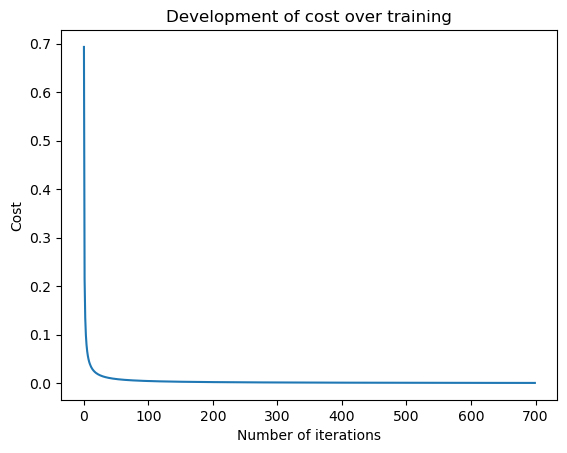

In [8]:
model = LogisticRegres()
weights, bias, costs = model.gradientdescent(X_train, y_train, 0.1, 700)

plt.plot(np.arange(700), costs)
plt.title("Development of cost over training")
plt.xlabel("Number of iterations")
plt.ylabel("Cost")
plt.show()

### 3. Оцениваем точность обученной модели

In [9]:
print(f"Accuracy of model on train data is {100 - np.sum(np.abs(model.prediction(X_train) - y_train)) * (100 / X_train.shape[0])} %")
print(f"Accuracy of model on test data is {100 - np.sum(np.abs(model.prediction(X_test) - y_test)) * (100 / X_test.shape[0])} %")

Accuracy of model on train data is 100.0 %
Accuracy of model on test data is 100.0 %
